# 🏥 Welkom bij de Introductie AI Workshop!
**Vandaag ga je zélf een AI model trainen!**

In het ziekenhuis helpt AI steeds vaker bij het scannen van röntgenfoto's of het herkennen van patronen in patiëntendossiers. Maar hoe leert een computer eigenlijk zoiets? Vandaag halen we de magie eruit en houden we het simpel: we gaan een AI trainen om het verschil te zien tussen **katten en honden**.

**Hoe werkt dit document?**
Dit is een interactief notitieblok. Je leest de uitleg en drukt daarna op de 'Play' knop ▶️ bij het code-blok eronder (of gebruik `Shift + Enter`) om de computer een taak te laten uitvoeren. Laten we beginnen!

## 🛠️ Stap 1: De Gereedschapskist Openen
Voordat we kunnen beginnen, moeten we wat hulpmiddelen klaarzetten. Zie dit als het klaarzetten van je instrumenten en protocollen voor een ingreep. We laden hier "pakketjes" in die de computer helpen om plaatjes te openen en slimme berekeningen te maken.

In [1]:
import os
import tarfile
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import random

from PIL import Image
from sklearn.model_selection import train_test_split

## 📸 Stap 2: De Patiëntendossiers (Foto's) Ophalen
Een arts leert in opleiding door heel veel voorbeelden te zien. Voor AI is dat precies hetzelfde! Om onze AI te trainen, hebben we een grote map met duizenden foto's van honden en katten nodig. We downloaden deze map nu automatisch van het internet.

In [2]:
images_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"

if not os.path.exists("images"):
    print("Downloading dataset...")
    urllib.request.urlretrieve(images_url, "images.tar.gz")

    with tarfile.open("images.tar.gz") as tar:
        tar.extractall()

print("Dataset klaar")

Dataset klaar


## ✂️ Stap 3: De Gegevens Voorbereiden
Computers hebben geen ogen; ze zien alleen wiskundige getallen. Om de AI goed te laten leren, moeten we de foto's netjes ordenen:
1. We kiezen eerlijk **1000 katten** en **1000 honden**.
2. We knippen alle foto's op exact hetzelfde formaat (64 bij 64 pixels).
3. We zetten de kleuren om in getallen tussen de 0 en 1, zodat de AI er straks makkelijk mee kan rekenen.

In [3]:
IMAGE_SIZE = 64
MAX_PER_CLASS = 1000  # Verhoogd voor een betere accuracy

X = []
y = []

# Haal alle jpg bestanden op
all_files = [f for f in os.listdir("images") if f.endswith(".jpg")]

# BELANGRIJK: Shuffle de lijst zodat je een mix van alle rassen krijgt!
random.shuffle(all_files)

cat_count = 0
dog_count = 0

for file in all_files:
    # Katten beginnen met hoofdletter, honden met kleine letter
    label = 0 if file[0].isupper() else 1

    if label == 0 and cat_count >= MAX_PER_CLASS:
        continue
    if label == 1 and dog_count >= MAX_PER_CLASS:
        continue

    path = os.path.join("images", file)

    img = Image.open(path).convert("RGB")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))

    X.append(np.array(img))
    y.append(label)

    if label == 0:
        cat_count += 1
    else:
        dog_count += 1

# BELANGRIJK: Normaliseer de pixels naar waarden tussen 0 en 1
X = np.array(X) / 255.0
y = np.array(y)

print("Shape van de dataset:", X.shape)

Shape van de dataset: (2000, 64, 64, 3)


## 👀 Stap 4: Even Spieken
Zijn onze data en foto's goed ingeladen? Laten we er willekeurig 9 uit de stapel pakken om te kijken hoe de computer ze heeft klaargezet. Ze zien er misschien een beetje wazig uit, omdat we ze expres heel klein hebben gemaakt (64x64)!

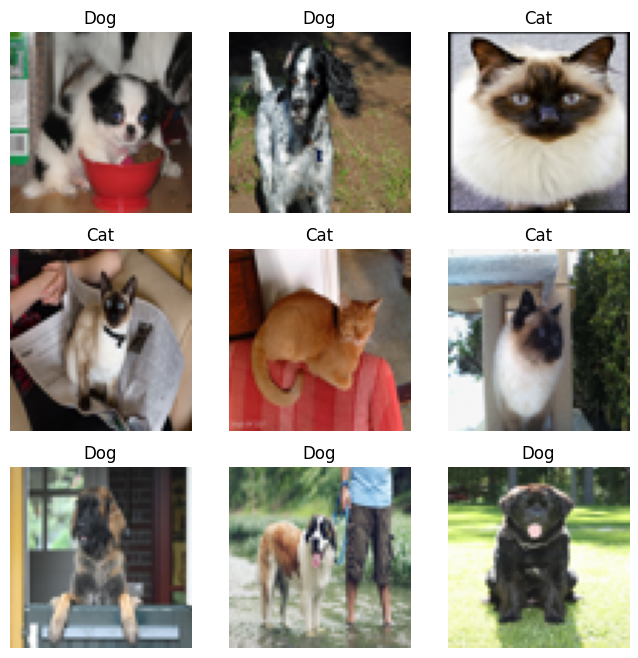

In [4]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i])
    plt.title("Dog" if y[i] else "Cat")
    plt.axis("off")

plt.show()

## 📚 Stap 5: Studiemateriaal vs. Het Examen
Als we de AI álle foto's laten zien tijdens het trainen, leert hij ze misschien gewoon uit zijn hoofd. Dat is niet de bedoeling! Daarom splitsen we onze data op in twee groepen:
* **Trainingsdata (80%):** Het studiemateriaal. Hiermee gaat de AI straks oefenen.
* **Testdata (20%):** Het eindexamen. Deze foto's houden we geheim tot het einde, om te testen of de AI écht het verschil tussen een kat en een hond snapt.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(1600, 64, 64, 3) (400, 64, 64, 3)


## 🧠 Stap 6: Het AI-Brein Bouwen
Nu gaan we de AI zelf ontwerpen! We bouwen een 'Neuraal Netwerk'.  

Zie dit als het bouwen van een visueel systeem, van het oog naar de hersenen.
* De eerste lagen ("Conv2D") zijn als de ogen: ze zoeken naar simpele dingen zoals randjes, vacht of kleuren.
* De diepere lagen plakken die informatie samen tot complexe vormen, zoals een snuit of een oor.
* De laatste laag neemt de beslissing: "Is dit een kat of een hond?"

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        16,
        (3,3),
        activation="relu",
        input_shape=(64,64,3)
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 🎯 Stap 7: De Regels van het Spel
We hebben het brein gebouwd, maar de AI weet nog niet *hoe* het moet leren. Hier stellen we het doel in. We vertellen de AI: *"Elke keer dat je een foto verkeerd inschat, krijg je strafpunten (Loss). Probeer dit getal zo laag mogelijk te maken, zodat je nauwkeurigheid (Accuracy) stijgt!"*

In [7]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 🎓 Stap 8: Naar School! (De Training)
Dit is het coolste (maar ook het langste) onderdeel: de AI gaat leren!
* **Epoch:** Eén 'epoch' betekent dat de AI de hele stapel studiefoto's één keer heeft doorgekeken.
* We laten hem **10 keer** door de stof heen gaan (10 epochs).

Kijk goed naar de getallen die straks verschijnen. Als het goed is zie je de `accuracy` (nauwkeurigheid) per ronde steeds een beetje stijgen. De computer wordt letterlijk slimmer waar je bij zit!

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=16
)

Epoch 1/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9215 - loss: 0.2307 - val_accuracy: 0.6800 - val_loss: 0.7250
Epoch 2/25
 63/100 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9288 - loss: 0.2115

## 📝 Stap 9: Het Eindexamen
De school is uit! Hoe goed is onze AI nu echt in de echte wereld? We laten hem het eindexamen doen op de 20% foto's die hij nog nooit eerder in zijn leven heeft gezien.
Een accuracy van `1.00` is een 10. Alles boven de 0.80 (80% goed) is voor dit simpele experiment een waanzinnig knappe prestatie!

In [9]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Accuracy: {accuracy:.2f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7265 - loss: 0.6798
Accuracy: 0.71


## 🔮 Stap 10: De AI in de Praktijk Zien!
Cijfers zijn leuk, maar we willen het natuurlijk met eigen ogen zien werken. Laten we 9 willekeurige foto's uit het eindexamen pakken en de AI vragen wat hij ziet.

* **Pred:** Wat de AI voorspelt *(Prediction)*.
* **True:** Wat de foto in werkelijkheid is.

Kijk maar mee hoeveel hij er goed heeft!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


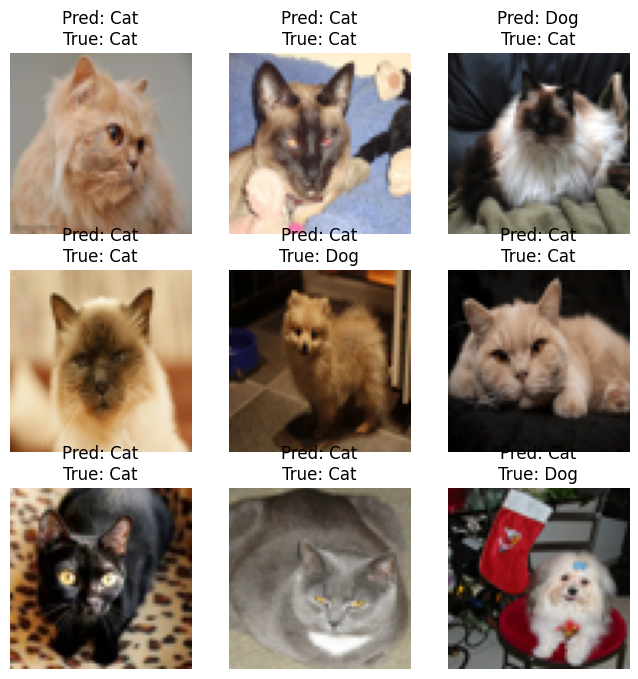

In [10]:
predictions = model.predict(X_test[:9])

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i])

    pred_label = "Dog" if predictions[i] > 0.5 else "Cat"
    true_label = "Dog" if y_test[i] else "Cat"

    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
    plt.axis("off")

plt.show()